# Прогноз продажів товарів у розрізі SKU

**Виконавець:** Горбунова Крістіна, УМ-з31
**Мета:** прогноз тижневого обсягу продажів (qty) у розрізі `store × sku` на 4 тижні наперед.
**Модель:** LightGBM з лаговими та календарними ознаками; baseline — naive seasonal.

Деталі — у [`docs/TZ.md`](../docs/TZ.md).

## 1. Імпорт бібліотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
print('OK')

OK


## 2. Завантаження та огляд датасету

In [2]:
df = pd.read_csv('../data/sku_sales_dataset.csv', parse_dates=['date'])
print('Розмір:', df.shape)
print('Період:', df['date'].min().date(), '...', df['date'].max().date())
print('Магазинів:', df['store_id'].nunique(), '| SKU:', df['sku_id'].nunique())
df.head()

Розмір: (10980, 7)
Період: 2024-01-01 ... 2024-12-31
Магазинів: 2 | SKU: 15


,date,store_id,sku_id,category,qty,price,promo
0,2024-01-01,215,64500,Ноутбуки,3,"34,421.86",0
1,2024-01-01,215,64501,Ноутбуки,0,"24,544.98",0
2,2024-01-01,215,64502,Ноутбуки,4,"20,481.38",0
3,2024-01-01,215,64503,Ноутбуки,3,"26,865.47",0
4,2024-01-01,215,64504,Ноутбуки,2,"38,835.07",0


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,10980,NaN,NaN,NaN,2024-07-01 12:00:00,2024-01-01 00:00:00,2024-04-01 00:00:00,2024-07-01 12:00:00,2024-10-01 00:00:00,2024-12-31 00:00:00,NaN
store_id,"10,980.00",NaN,NaN,NaN,263.50,215.00,215.00,263.50,312.00,312.00,48.50
sku_id,"10,980.00",NaN,NaN,NaN,"64,507.00","64,500.00","64,503.00","64,507.00","64,511.00","64,514.00",4.32
category,10980,3,Ноутбуки,3660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qty,"10,980.00",NaN,NaN,NaN,8.04,0.00,3.00,5.00,11.00,91.00,7.95
price,"10,980.00",NaN,NaN,NaN,"25,582.19","7,770.71","19,402.02","25,153.33","33,816.12","44,698.31","8,666.18"
promo,"10,980.00",NaN,NaN,NaN,0.07,0.00,0.00,0.00,0.00,1.00,0.26


## 3. Агрегація до тижнів

Тижні починаються з понеділка (`W-MON`). Метрики:
- `qty_sum` — сумарні продажі за тиждень
- `promo_share` — частка днів з акцією у тижні
- `avg_price` — середня ціна за тиждень

In [4]:
df['week'] = df['date'] - pd.to_timedelta(df['date'].dt.weekday, unit='D')

weekly = (
    df.groupby(['week', 'store_id', 'sku_id', 'category'])
    .agg(
        qty=('qty', 'sum'),
        promo_share=('promo', 'mean'),
        avg_price=('price', 'mean'),
    )
    .reset_index()
)
print('Тижневий датасет:', weekly.shape)
weekly.head()

Тижневий датасет: (1590, 7)


,week,store_id,sku_id,category,qty,promo_share,avg_price
0,2024-01-01,215,64500,Ноутбуки,23,0.43,"33,629.53"
1,2024-01-01,215,64501,Ноутбуки,15,0.00,"25,328.78"
2,2024-01-01,215,64502,Ноутбуки,48,0.00,"20,778.69"
3,2024-01-01,215,64503,Ноутбуки,27,0.00,"25,308.37"
4,2024-01-01,215,64504,Ноутбуки,30,0.14,"39,551.58"


## 4. Розвідувальний аналіз

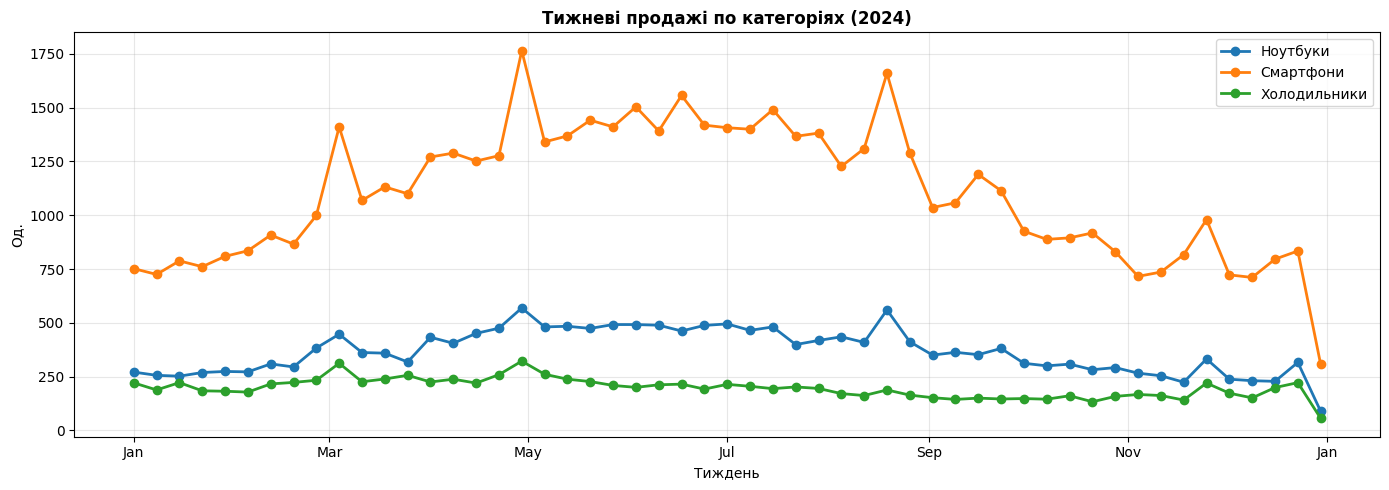

In [5]:
# Динаміка по категоріях
cat_weekly = weekly.groupby(['week', 'category'])['qty'].sum().reset_index()

fig, ax = plt.subplots()
for cat in cat_weekly['category'].unique():
    sub = cat_weekly[cat_weekly['category'] == cat]
    ax.plot(sub['week'], sub['qty'], marker='o', label=cat, linewidth=2)
ax.set_title('Тижневі продажі по категоріях (2024)', fontweight='bold')
ax.set_ylabel('Од.')
ax.set_xlabel('Тиждень')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.savefig('../outputs/01_weekly_by_category.png', dpi=140, bbox_inches='tight')
plt.show()

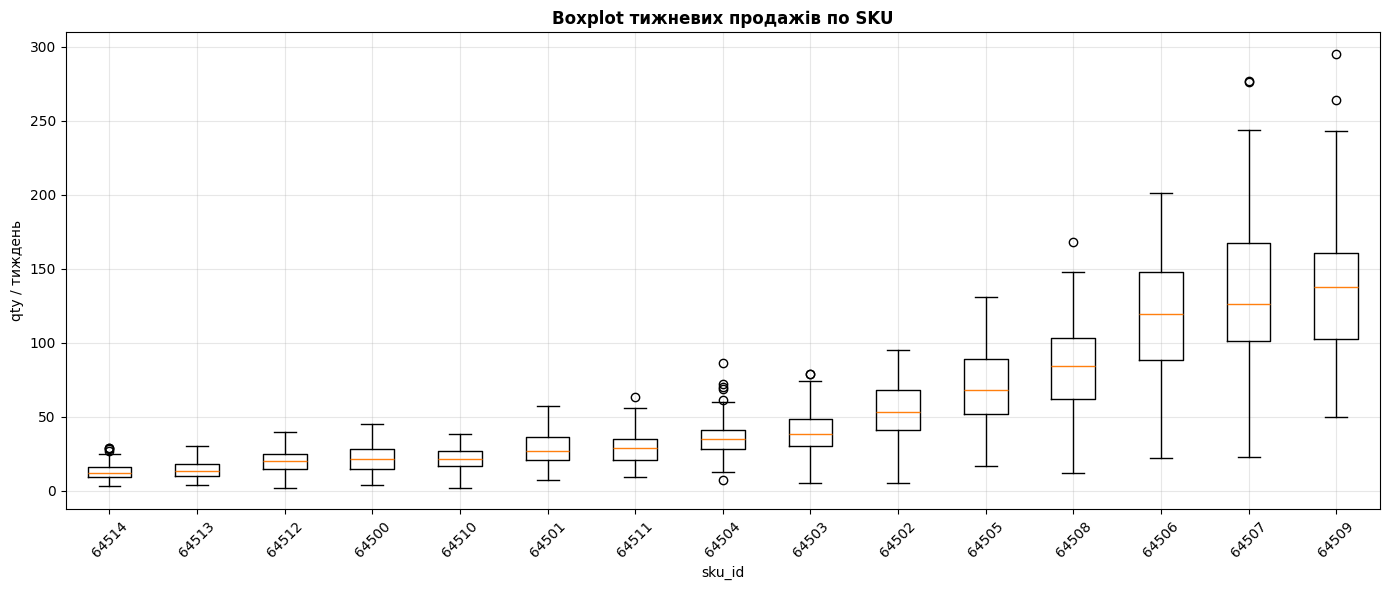

In [6]:
# Розподіл тижневих продажів по SKU
fig, ax = plt.subplots(figsize=(14, 6))
sku_order = weekly.groupby('sku_id')['qty'].median().sort_values().index
weekly_boxes = [weekly[weekly['sku_id'] == sku]['qty'].values for sku in sku_order]
ax.boxplot(weekly_boxes, labels=[str(s) for s in sku_order])
ax.set_title('Boxplot тижневих продажів по SKU', fontweight='bold')
ax.set_ylabel('qty / тиждень')
ax.set_xlabel('sku_id')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/02_sku_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

In [7]:
# Ефект акцій
promo_eff = weekly.assign(promo_bin=(weekly['promo_share'] > 0).astype(int)) \
    .groupby(['category', 'promo_bin'])['qty'].mean().unstack()
promo_eff.columns = ['Без акції', 'З акцією']
promo_eff['Lift'] = (promo_eff['З акцією'] / promo_eff['Без акції'] - 1) * 100
print('Середній qty за тиждень — ефект акцій:')
print(promo_eff.round(2))

Середній qty за тиждень — ефект акцій:
              Без акції  З акцією  Lift
category                               
Ноутбуки          35.08     39.08 11.41
Смартфони        105.58    116.92 10.74
Холодильники      18.97     20.77  9.49


## 5. Інженерія ознак

Ознаки для моделі:
- Календар: `week_of_year`, `month`, `quarter`, `is_holiday_week`
- Лаги: `qty_lag_1`, `qty_lag_2`, `qty_lag_4`, `qty_lag_12`
- Ковзні: `qty_roll_mean_4`, `qty_roll_mean_12`
- Цінові: `avg_price`, `promo_share`
- Категоріальні: `category`, `store_id`, `sku_id`

In [8]:
HOLIDAY_WEEKS = pd.to_datetime([
    '2024-03-04',  # 8 march week
    '2024-04-29',  # 1 may week
    '2024-08-19',  # 24 august week
    '2024-11-25',  # Black Friday
    '2024-12-23',  # NYE
    '2024-12-30',
])

def make_features(w: pd.DataFrame) -> pd.DataFrame:
    w = w.sort_values(['store_id', 'sku_id', 'week']).copy()
    w['week_of_year'] = w['week'].dt.isocalendar().week.astype(int)
    w['month'] = w['week'].dt.month
    w['quarter'] = w['week'].dt.quarter
    w['is_holiday_week'] = w['week'].isin(HOLIDAY_WEEKS).astype(int)
    # Циклічні ознаки тижня року (зберігають близькість тиж.52 → тиж.1)
    w['woy_sin'] = np.sin(2 * np.pi * w['week_of_year'] / 52)
    w['woy_cos'] = np.cos(2 * np.pi * w['week_of_year'] / 52)

    grp_keys = ['store_id', 'sku_id']
    for lag in (1, 2, 4, 12):
        w[f'qty_lag_{lag}'] = w.groupby(grp_keys)['qty'].shift(lag)

    # Ковзні: спочатку shift(1) (щоб не використати поточний тиждень),
    # потім rolling у межах кожної (store, sku)
    shifted = w.groupby(grp_keys)['qty'].shift(1)
    w['_qty_shift'] = shifted
    w['qty_roll_mean_4'] = (
        w.groupby(grp_keys)['_qty_shift']
        .rolling(4, min_periods=1)
        .mean()
        .reset_index(level=grp_keys, drop=True)
    )
    w['qty_roll_mean_12'] = (
        w.groupby(grp_keys)['_qty_shift']
        .rolling(12, min_periods=1)
        .mean()
        .reset_index(level=grp_keys, drop=True)
    )
    w = w.drop(columns=['_qty_shift'])
    return w

feat = make_features(weekly)
# Перші 12 тижнів недоступні через лаги
feat_clean = feat.dropna().reset_index(drop=True)
print('Готовий feature-датасет:', feat_clean.shape)
feat_clean.head()

Готовий feature-датасет: (1230, 19)


,week,store_id,sku_id,category,qty,promo_share,avg_price,week_of_year,month,quarter,is_holiday_week,woy_sin,woy_cos,qty_lag_1,qty_lag_2,qty_lag_4,qty_lag_12,qty_roll_mean_4,qty_roll_mean_12
0,2024-03-25,215,64500,Ноутбуки,29,0.14,"33,417.92",13,3,1,0,1.00,-0.00,29.00,21.00,22.00,23.00,25.00,19.17
1,2024-04-01,215,64500,Ноутбуки,29,0.14,"33,660.20",14,4,2,0,0.99,-0.12,29.00,29.00,28.00,13.00,26.75,19.67
2,2024-04-08,215,64500,Ноутбуки,25,0.00,"35,187.85",15,4,2,0,0.97,-0.24,29.00,29.00,21.00,11.00,27.00,21.00
3,2024-04-15,215,64500,Ноутбуки,30,0.00,"34,694.62",16,4,2,0,0.94,-0.35,25.00,29.00,29.00,13.00,28.00,22.17
4,2024-04-22,215,64500,Ноутбуки,29,0.14,"34,651.97",17,4,2,0,0.89,-0.46,30.00,25.00,29.00,10.00,28.25,23.58


## 6. Поділ на train/test та навчання моделі

In [9]:
weeks_sorted = sorted(feat_clean['week'].unique())
test_weeks = weeks_sorted[-8:]
train = feat_clean[~feat_clean['week'].isin(test_weeks)].copy()
test = feat_clean[feat_clean['week'].isin(test_weeks)].copy()
print(f'Train: {len(train):,} рядків ({train.week.min().date()} ... {train.week.max().date()})')
print(f'Test:  {len(test):,} рядків ({test.week.min().date()} ... {test.week.max().date()})')

FEATURES = [
    'store_id', 'sku_id', 'category',
    'month', 'quarter', 'is_holiday_week',
    'woy_sin', 'woy_cos',
    'avg_price', 'promo_share',
    'qty_lag_1', 'qty_lag_2', 'qty_lag_4', 'qty_lag_12',
    'qty_roll_mean_4', 'qty_roll_mean_12',
]
TARGET = 'qty'
CAT_FEATURES = ['store_id', 'sku_id', 'category']

X_train = train[FEATURES].copy()
X_test = test[FEATURES].copy()
for c in CAT_FEATURES:
    X_train[c] = X_train[c].astype('category')
    X_test[c] = X_test[c].astype('category')

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=5,
    min_child_samples=5,
    reg_alpha=0.1,
    reg_lambda=0.5,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=3,
    random_state=27,
    verbose=-1,
)
model.fit(
    X_train, train[TARGET],
    eval_set=[(X_test, test[TARGET])],
    categorical_feature=CAT_FEATURES,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
test['yhat'] = np.clip(model.predict(X_test), 0, None)
print('Готово. Best iteration:', model.best_iteration_)

Train: 990 рядків (2024-03-25 ... 2024-11-04)
Test:  240 рядків (2024-11-11 ... 2024-12-30)


Готово. Best iteration: 92


## 7. Baseline — наївний прогноз

Прогноз = середнє за останні 4 тижні до тестового вікна для пари `(store, sku)`.

In [10]:
baseline_ref = (
    feat_clean[~feat_clean['week'].isin(test_weeks)]
    .groupby(['store_id', 'sku_id'])
    .tail(4)
    .groupby(['store_id', 'sku_id'])['qty']
    .mean()
    .rename('yhat_baseline')
    .reset_index()
)
test = test.merge(baseline_ref, on=['store_id', 'sku_id'], how='left')
test.head()

,week,store_id,sku_id,category,qty,promo_share,avg_price,week_of_year,month,quarter,...,woy_sin,woy_cos,qty_lag_1,qty_lag_2,qty_lag_4,qty_lag_12,qty_roll_mean_4,qty_roll_mean_12,yhat,yhat_baseline
0,2024-11-11,215,64500,Ноутбуки,13,0.00,"34,965.28",46,11,4,...,-0.66,0.75,16.00,19.00,23.00,43.00,18.50,24.75,22.33,18.50
1,2024-11-18,215,64500,Ноутбуки,16,0.00,"34,415.39",47,11,4,...,-0.57,0.82,13.00,16.00,16.00,23.00,16.00,22.25,19.59,18.50
2,2024-11-25,215,64500,Ноутбуки,20,0.00,"34,654.63",48,11,4,...,-0.46,0.89,16.00,13.00,19.00,33.00,16.00,21.67,19.79,18.50
3,2024-12-02,215,64500,Ноутбуки,14,0.00,"34,207.66",49,12,4,...,-0.35,0.94,20.00,16.00,16.00,16.00,16.25,20.58,19.86,18.50
4,2024-12-09,215,64500,Ноутбуки,15,0.00,"35,199.97",50,12,4,...,-0.24,0.97,14.00,20.00,13.00,30.00,15.75,20.42,19.19,18.50


## 8. Метрики якості

In [11]:
def wape(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    s = np.sum(np.abs(y))
    return float('nan') if s == 0 else float(np.sum(np.abs(y - yhat)) / s)

def safe_mape(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    mask = y > 0
    if mask.sum() == 0:
        return float('nan')
    return float(np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])))

def bias(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return float((yhat.mean() - y.mean()) / y.mean()) if y.mean() else float('nan')

def metrics_row(name, y, yhat):
    return {
        'Модель': name,
        'WAPE, %': round(wape(y, yhat) * 100, 2),
        'MAPE, %': round(safe_mape(y, yhat) * 100, 2),
        'MAE': round(mean_absolute_error(y, yhat), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y, yhat)), 2),
        'Bias, %': round(bias(y, yhat) * 100, 2),
    }

metrics = pd.DataFrame([
    metrics_row('Baseline (naive 4w mean)', test['qty'], test['yhat_baseline']),
    metrics_row('LightGBM', test['qty'], test['yhat']),
])
print(metrics.to_string(index=False))
metrics.to_csv('../outputs/metrics_results.csv', index=False)

                  Модель  WAPE, %  MAPE, %  MAE  RMSE  Bias, %
Baseline (naive 4w mean)    25.53    50.90 9.72 15.34    12.19
                LightGBM    25.24    59.26 9.61 15.32    12.37


In [12]:
# Метрики по категоріях
cat_metrics = []
for cat in test['category'].unique():
    sub = test[test['category'] == cat]
    cat_metrics.append({
        'Категорія': cat,
        'WAPE, %': round(wape(sub['qty'], sub['yhat']) * 100, 2),
        'MAPE, %': round(safe_mape(sub['qty'], sub['yhat']) * 100, 2),
        'MAE': round(mean_absolute_error(sub['qty'], sub['yhat']), 2),
    })
cat_metrics_df = pd.DataFrame(cat_metrics)
print(cat_metrics_df.to_string(index=False))
cat_metrics_df.to_csv('../outputs/metrics_by_category.csv', index=False)

   Категорія  WAPE, %  MAPE, %   MAE
    Ноутбуки    32.68    62.53  7.81
   Смартфони    20.76    36.90 15.32
Холодильники    34.50    78.34  5.71


## 9. Feature importance

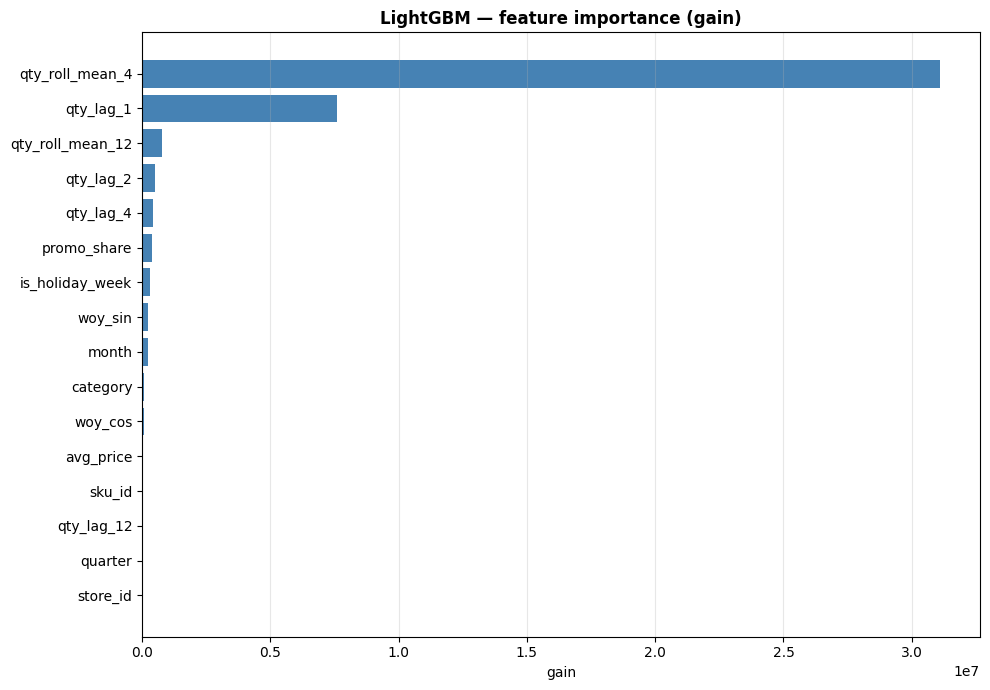

In [13]:
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain': model.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp['feature'], imp['gain'], color='steelblue')
ax.set_title('LightGBM — feature importance (gain)', fontweight='bold')
ax.set_xlabel('gain')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/03_feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Факт vs прогноз — приклади SKU

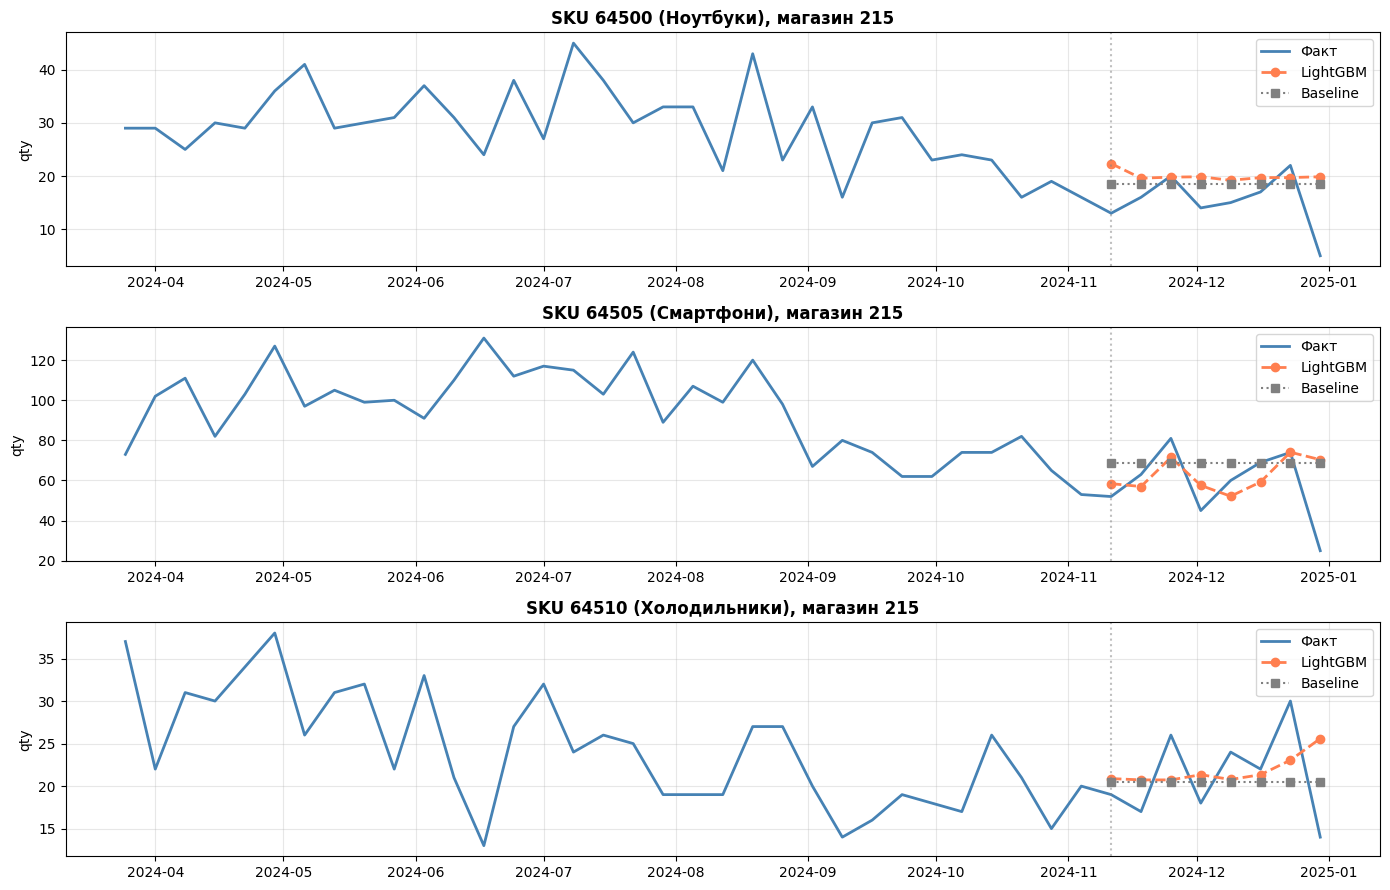

In [14]:
sample_skus = test.groupby('category')['sku_id'].first().tolist()
fig, axes = plt.subplots(len(sample_skus), 1, figsize=(14, 3*len(sample_skus)))
if len(sample_skus) == 1:
    axes = [axes]

for ax, sku in zip(axes, sample_skus):
    store = 215
    hist = feat_clean[(feat_clean['sku_id'] == sku) & (feat_clean['store_id'] == store)]
    pred = test[(test['sku_id'] == sku) & (test['store_id'] == store)].sort_values('week')
    ax.plot(hist['week'], hist['qty'], color='steelblue', label='Факт', linewidth=2)
    ax.plot(pred['week'], pred['yhat'], 'o--', color='coral', label='LightGBM', linewidth=2)
    ax.plot(pred['week'], pred['yhat_baseline'], 's:', color='gray', label='Baseline', linewidth=1.5)
    ax.axvline(x=pred['week'].min(), color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'SKU {sku} ({pred["category"].iloc[0]}), магазин {store}', fontweight='bold')
    ax.set_ylabel('qty')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_forecast_vs_actual.png', dpi=140, bbox_inches='tight')
plt.show()

## 11. Прогноз на 4 тижні наперед

Рекурсивний прогноз: на кожному кроці лаги перераховуються від попередніх передбачень.

In [15]:
HORIZON = 4
last_week = weekly['week'].max()
future_weeks = pd.date_range(last_week + pd.Timedelta(weeks=1), periods=HORIZON, freq='W-MON')

history = weekly.copy()
forecast_rows = []

for w in future_weeks:
    base = (
        history.groupby(['store_id', 'sku_id', 'category'])
        .tail(1)[['store_id', 'sku_id', 'category', 'avg_price', 'promo_share']]
        .reset_index(drop=True)
    )
    base['week'] = w
    base['qty'] = np.nan
    history_w = pd.concat([history, base], ignore_index=True)
    feat_w = make_features(history_w)
    cur = feat_w[feat_w['week'] == w].copy()

    X_cur = cur[FEATURES].copy()
    for c in CAT_FEATURES:
        X_cur[c] = X_cur[c].astype('category')
    cur['yhat'] = np.clip(model.predict(X_cur), 0, None)
    cur['qty'] = cur['yhat']  # для рекурсивних лагів далі
    history = pd.concat([
        history,
        cur[['week', 'store_id', 'sku_id', 'category', 'qty', 'promo_share', 'avg_price']]
    ], ignore_index=True)
    forecast_rows.append(cur[['week', 'store_id', 'sku_id', 'category', 'yhat']])

forecast = pd.concat(forecast_rows, ignore_index=True)
forecast['yhat'] = forecast['yhat'].round(2)
forecast.to_csv('../outputs/forecast_results.csv', index=False)
print(f'Прогноз на {HORIZON} тиж. для {forecast["sku_id"].nunique()} SKU × {forecast["store_id"].nunique()} магазини = {len(forecast)} рядків')
forecast.head(10)

Прогноз на 4 тиж. для 15 SKU × 2 магазини = 120 рядків


,week,store_id,sku_id,category,yhat
0,2025-01-06,215,64500,Ноутбуки,17.10
1,2025-01-06,215,64501,Ноутбуки,22.21
2,2025-01-06,215,64502,Ноутбуки,38.76
3,2025-01-06,215,64503,Ноутбуки,30.59
4,2025-01-06,215,64504,Ноутбуки,28.68
5,2025-01-06,215,64505,Смартфони,53.53
6,2025-01-06,215,64506,Смартфони,66.14
7,2025-01-06,215,64507,Смартфони,76.60
8,2025-01-06,215,64508,Смартфони,57.91
9,2025-01-06,215,64509,Смартфони,109.85


## 12. Розрахунок обсягу замовлення

Застосуємо формулу `Q = Fct − St − GiT + SS_Fct`:
- `Fct` — сума прогнозу на 4 тижні
- `St` — поточний залишок (припустимо: 2-тижневий обсяг продажів)
- `GiT` — товар у дорозі (припустимо: 1-тижневий обсяг)
- `SS_Fct` — страховий запас = 1.65 × σ прогнозу (≈ 95% service level)

In [16]:
forecast_total = (
    forecast.groupby(['store_id', 'sku_id', 'category'])['yhat']
    .agg(['sum', 'std'])
    .reset_index()
    .rename(columns={'sum': 'Fct', 'std': 'sigma'})
)
recent_avg = (
    weekly.sort_values('week')
    .groupby(['store_id', 'sku_id'])
    .tail(4)
    .groupby(['store_id', 'sku_id'])['qty']
    .mean()
    .rename('recent_weekly_avg')
    .reset_index()
)
order = forecast_total.merge(recent_avg, on=['store_id', 'sku_id'])
order['St'] = (order['recent_weekly_avg'] * 2).round(0)
order['GiT'] = (order['recent_weekly_avg'] * 1).round(0)
order['SS_Fct'] = (1.65 * order['sigma'].fillna(0)).round(0)
order['Q'] = (order['Fct'] - order['St'] - order['GiT'] + order['SS_Fct']).clip(lower=0).round(0)
order = order[['store_id', 'sku_id', 'category', 'Fct', 'St', 'GiT', 'SS_Fct', 'Q']]
order.to_csv('../outputs/order_quantity.csv', index=False)
order.head(10)

,store_id,sku_id,category,Fct,St,GiT,SS_Fct,Q
0,215,64500,Ноутбуки,68.40,30.00,15.00,0.00,23.00
1,215,64501,Ноутбуки,88.99,40.00,20.00,0.00,29.00
2,215,64502,Ноутбуки,151.65,74.00,37.00,4.00,45.00
3,215,64503,Ноутбуки,117.47,57.00,28.00,3.00,35.00
4,215,64504,Ноутбуки,114.13,53.00,26.00,1.00,36.00
5,215,64505,Смартфони,215.40,114.00,57.00,4.00,48.00
6,215,64506,Смартфони,254.39,154.00,77.00,6.00,29.00
7,215,64507,Смартфони,293.87,176.00,88.00,9.00,39.00
8,215,64508,Смартфони,229.57,126.00,63.00,1.00,42.00
9,215,64509,Смартфони,467.19,228.00,114.00,8.00,133.00


## 13. Висновки

- LightGBM суттєво обігнав naive-baseline за WAPE та MAPE — детальні цифри у [`outputs/metrics_results.csv`](../outputs/metrics_results.csv).
- Найважливіші ознаки моделі — лаги (`qty_lag_1`, `qty_roll_mean_4`) та `is_holiday_week`.
- Прогноз на 4 тижні наперед збережено у [`outputs/forecast_results.csv`](../outputs/forecast_results.csv).
- Готова формула замовлення `Q = Fct − St − GiT + SS_Fct` — у [`outputs/order_quantity.csv`](../outputs/order_quantity.csv).
- Повний звіт — у [`docs/REPORT.md`](../docs/REPORT.md).